In [1]:
import numpy as np
import getdist.plots
import matplotlib.pyplot as plt
import yaml
import sys
import os
import shutil

# So the Jupyter kernel finds LaTeX when started from Cursor/VS Code
if not shutil.which('pdflatex'):
    os.environ['PATH'] = '/Library/TeX/texbin:' + os.environ.get('PATH', '')

# Load parameter configuration files
# params_names.yaml contains the mapping from parameter names to LaTeX labels
with open("params_names.yaml", "r") as file:
    params_dic = yaml.safe_load(file)

# params_model_shear.yaml contains fiducial values and prior ranges
with open("params_model_shear.yaml", "r") as file:
    fiducials = yaml.safe_load(file)
print(shutil.which("latex"))

/Library/TeX/texbin/latex


In [2]:
import os

# Inject TeX into PATH for this Python process
os.environ["PATH"] = "/Library/TeX/texbin:" + os.environ["PATH"]

import shutil
print("Latex seen by Python:", shutil.which("latex"))

#import matplotlib.pyplot as plt
#plt.rcParams["text.usetex"] = True

Latex seen by Python: /Library/TeX/texbin/latex


In [3]:
# Set up plotting style and colors
import seaborn as sns
sns.set_theme(style="ticks")
colors = sns.color_palette("Set2")  # Use seaborn Set2 color palette

plt.ioff()  # prevent post-execute redraws that can trigger LaTeX errors in callbacks

# Use matplotlib's built-in text (no LaTeX required)
from matplotlib import rc
rc('text', usetex=False)
rc('font', **{'family': 'serif', 'serif': ['DejaVu Serif']})


In [4]:
chain = np.load('../sampling/chains/chain_checkpoint_3x2pt_DR1_area_1589_realistic_new_covmat_TR1v1.1_cpl.npz', allow_pickle=True)


In [9]:
#chain, derived, weights, logl, param_names,derived_names,logz,chain_time, chain_time_hms, fiducial
fiducials  = chain['fiducial'].flat[0]
fiducials['h'] = fiducials['H0']/100.
fiducials['logAs'] = np.log(1e10*fiducials['As'])
fiducials['omch2'] = fiducials['Omega_cdm0']*fiducials['h']*fiducials['h']
fiducials['ombh2'] = fiducials['Omega_b0']*fiducials['h']*fiducials['h']
fiducials['sigma8_0'] = 0.8120011480183122
fiducials['Omega_m'] = (fiducials['omch2']+fiducials['ombh2']+fiducials['mnu']/93.14)/fiducials['h']**2
fiducials['S8'] = fiducials['sigma8_0']*np.sqrt(fiducials['Omega_m']/0.3)
fiducials['mnu']

0.077

In [21]:
# List of MCMC chain files to compare
file_paths = ['../sampling/chains/chain_checkpoint_3x2pt_DR1_area_1589_realistic_new_covmat_TR1v1.1_cpl.npz',
             '../sampling/chains/chain_checkpoint_3x2pt_DR1_area_1589_realistic_new_covmat_TR1v1.1_cpl_desidr2.npz',
             '../sampling/chains/chain_checkpoint_3x2pt_DR1_area_1589_realistic_new_covmat_TR1v1.1_cpl_desy5sn.npz',
             '../sampling/chains/chain_checkpoint_3x2pt_DR1_area_1589_realistic_new_covmat_TR1v1.1_cpl_desy5sn_desidr2bao.npz',
             

 ]  

# Legend labels for each chain (LaTeX formatting supported)
legend_labels = [
    '3x2pt+CMB-priors',
    '+DESI DR2 BAO',
    '+DESY5 SN',
    '+BAO+SN',
    #'3x2pt+CMB+DESSN',
    #'DESIBAO+CMB'

]

n_samples = len(file_paths)
chains_info = {}

# Load each MCMC chain file
for i in range(n_samples):
    file_path = file_paths[i]  
    
    # Load numerical data from chain file
    chain_npz = np.load(file_path, allow_pickle=True)
        
    
    # Store chain data and parameter names
    chains_info[i] = {}
    chains_info[i]['chain'] = np.vstack([chain_npz['chain'].flat[0][par] for par in chain_npz['param_names']]).T
    chains_info[i]['chain'] = np.hstack((chains_info[i]['chain'], chain_npz['derived'].flat[0]['sigma8_0'][:, np.newaxis]))
    print(chains_info[i]['chain'].shape)
    chains_info[i]['weights'] = chain_npz['weights']
    chains_info[i]['logl'] = chain_npz['logl']
    chains_info[i]['pars'] = np.hstack((chain_npz['param_names'], chain['derived_names']))
    chains_info[i]['fiducial'] = chain_npz['fiducial'].flat[0]
    if 'w_i' in chains_info[i]['fiducial']:
        for j in range(len(chains_info[i]['fiducial']['w_i'])):
            chains_info[i]['fiducial']['w'+str(j+1)] = chains_info[i]['fiducial']['w_i'][j]

(31496, 32)
(30628, 32)
(34100, 32)
(43028, 32)


In [22]:
# =============================================================================
# GETDIST SAMPLE PREPARATION
# =============================================================================

samples = []    
for i in range(n_samples):
    # Create GetDist MCSamples object for each chain
    samples.append(
        getdist.MCSamples(
            # Sample data (excluding log-likelihood and weight columns)
            samples = chains_info[i]['chain'],
            # Parameter names
            names = [i for i in chains_info[i]['pars']],
            # Sample weights (exponential of log-likelihood)
            weights=np.exp(chains_info[i]['weights']),
            # LaTeX labels for parameters (from params_dic)
            labels = [params_dic[p] for p in chains_info[i]['pars']],
            # Smoothing settings for 1D and 2D distributions
            settings={'smooth_scale_2D':0.35, 'smooth_scale_1D':0.35},
            # Parameter ranges for plotting
            #ranges = Ranges
            ranges={'w0':[-3., -0.5], 'wa':[-3, 3]}
        ) 
    )
    mnu = chains_info[i]['fiducial']['mnu']
    # Get parameter object (unused but kept for compatibility)
    p = samples[i].getParams() 
    samples[i].addDerived(p.H0/100., 'h','h')
    p = samples[i].getParams() 
    samples[i].addDerived((p.omch2+p.ombh2+mnu/93.14)/p.h**2, 'Omega_m','\Omega_{\\rm m}')
    p = samples[i].getParams() 
    samples[i].addDerived(p.sigma8_0*np.sqrt(p.Omega_m/0.3), 'S8', 'S_8')
    samples[i].addDerived(p.wa, 'wa_shift', 'w_a')


Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


In [34]:
# Create GetDist subplot plotter
g = getdist.plots.getSubplotPlotter(subplot_size=1.3)

# Configure plot appearance settings
plt.rcParams.update({'font.size':16})
g.settings.legend_fontsize=22      # Legend text size
g.settings.axes_fontsize=18        # Axis tick labels size  
g.settings.axes_labelsize=20       # Axis labels size
g.settings.linewidth=4             # Contour line width
g.settings.figure_legend_frame = False  # Remove legend frame


In [35]:
chains_info[0]['pars']

array(['omch2', 'ombh2', 'H0', 'logAs', 'ns', 'AIA', 'EtaIA', 'w0', 'wa',
       'b1_photo_poly0', 'b1_photo_poly1', 'b1_photo_poly2',
       'b1_photo_poly3', 'multiplicative_bias_1', 'multiplicative_bias_2',
       'multiplicative_bias_3', 'multiplicative_bias_4',
       'multiplicative_bias_5', 'multiplicative_bias_6', 'dz_pos_1',
       'dz_pos_2', 'dz_pos_3', 'dz_pos_4', 'dz_pos_5', 'dz_pos_6',
       'dz_shear_1', 'dz_shear_2', 'dz_shear_3', 'dz_shear_4',
       'dz_shear_5', 'dz_shear_6', 'sigma8_0'], dtype='<U21')

In [40]:
ModelPars = ['Omega_m', 'S8',  'h', 'w0', 'wa'] #chains_info[0]['pars']#['Omega_m', 'S8',  'h', 'w0', 'wa', 'AIA', 'EtaIA']

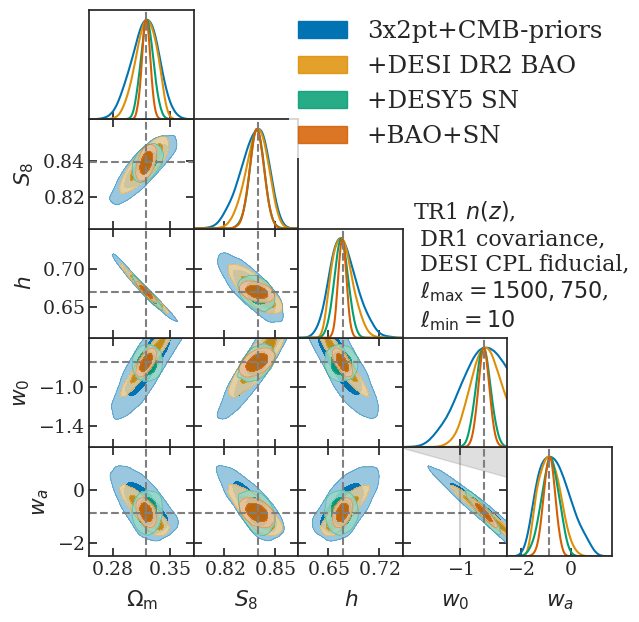

In [41]:
# =============================================================================
# CREATE TRIANGLE PLOT
# =============================================================================

# Generate the main triangle (corner) plot
g.triangle_plot(
    samples,                          # List of MCSamples objects
    ModelPars,                        # Parameters to include in plot
    legend_labels = legend_labels,    # Labels for legend
    legend_loc = 'upper right',       # Legend position
    # Filled contour styling for each sample
    contour_args = [
        {'filled':True, 'color': colors[0]}, 
        {'filled':True, 'color': colors[1], 'ls': '-'}, 
        {'filled':True, 'color': colors[2], 'ls': '-'},
        {'filled':True, 'color': colors[3], 'ls': '-'},  
        {'filled':True, 'color': colors[4], 'ls': '-'},  
        {'filled':True, 'color': colors[5], 'ls': '-'}
    ], 
    # 1D marginalized distribution styling
    line_args=[
        {'color': colors[0], 'ls': '-'}, 
        {'color': colors[1], 'ls': '-'}, 
        {'color': colors[2], 'ls': '-'}, 
        {'color': colors[3], 'ls': '-'}, 
        {'color': colors[4], 'ls': '-'}, 
        {'color': colors[5], 'ls': '-'}
    ]
)

xx = np.linspace(-2., 0., 100)

if fiducials != None:
    for i in range(len(ModelPars)):
        for j in range(i+1):
            ax = g.subplots[i,j]
            
            # Add horizontal line for fiducial value of y-parameter (for 2D plots)
            if i != j and ModelPars[i] in fiducials and fiducials[ModelPars[i]] != None:
                ax.axhline(fiducials[ModelPars[i]], lw=1.5, color='tab:gray', linestyle='--')
                if ModelPars[i] == 'wa' and ModelPars[j] == 'w0':
                    #ax.plot(xx, -xx, color='tab:gray', linestyle='--')
                    ax.fill_between(xx, -xx, np.ones(len(xx))*4, color='grey', alpha=0.25)
                    ax.axvline(x=-1., color='k',ls='-', alpha=0.2)  
            # Add vertical line for fiducial value of x-parameter
            if ModelPars[j] in fiducials and fiducials[ModelPars[j]] != None:
                ax.axvline(fiducials[ModelPars[j]], lw=1.5, color='tab:gray', linestyle='--')
                if ModelPars[i] == 'wa' and ModelPars[j] == 'w0':
                    ax.axvline(x=0., color='k',ls='-', alpha=0.2)  

# Position for annotation (subplot index)
num = 2
annotation_text = 'TR1 $n(z)$,\n DR1 covariance,\n DESI CPL fiducial,\n $\ell_{\\rm max}=1500, 750$,\n $\ell_{\\rm min}=10$'
# Add text annotation to a specific subplot
ax = g.subplots[num, num]
ax.annotate(annotation_text, (1.1, 0.1), xycoords='axes fraction', 
           clip_on=False, fontsize=16) 
plt.show()

In [27]:
samples_desi_cmb_sn=getdist.loadMCSamples('/Users/s2265800/Desktop/GitHub/evolvingDS/chains_w0wa/DESI_CMB_SN5/chain',settings={'ignore_rows':0.3})
p = samples_desi_cmb_sn.getParams()
samples_desi_cmb_sn.addDerived(p.w, 'w0', 'w_0')
samples_desi_cmb_sn.addDerived(p.wa, 'wa_shift', 'w_a')

In [28]:
samples_desi_cmb=getdist.loadMCSamples('/Users/s2265800/Desktop/GitHub/evolvingDS/chains_w0wa/DESI_CMBcompr/chain',settings={'ignore_rows':0.3})
p = samples_desi_cmb.getParams()
samples_desi_cmb.addDerived(p.w-0.33, 'w0', 'w_0')
samples_desi_cmb.addDerived(p.wa+0.89, 'wa_shift', 'w_a')


In [29]:
samples_desi_des_sn_file = np.genfromtxt('/Users/s2265800/Desktop/GitHub/evolvingDS/chains_w0wa/desi-bao-all_desy5sn_desy3x2pt.1.txt')
samples_desi_des_sn_file[:, 2]=samples_desi_des_sn_file[:, 2]+0.021
samples_desi_des_sn_file[:, 3]=samples_desi_des_sn_file[:, 3]+0.04
samples_desi_des_sn = getdist.MCSamples(
            # Sample data (excluding log-likelihood and weight columns)
            samples = samples_desi_des_sn_file[:, 2:-2],
            # Parameter names
            names = ['w0', 'wa_shift'],
            # Sample weights (exponential of log-likelihood)
            weights=samples_desi_des_sn_file[:, 0],
            # LaTeX labels for parameters (from params_dic)
            labels =  ['$w_0$', '$w_a$'],
            # Smoothing settings for 1D and 2D distributions
            settings={'smooth_scale_2D':0.35, 'smooth_scale_1D':0.35},
        ) 

Removed no burn in


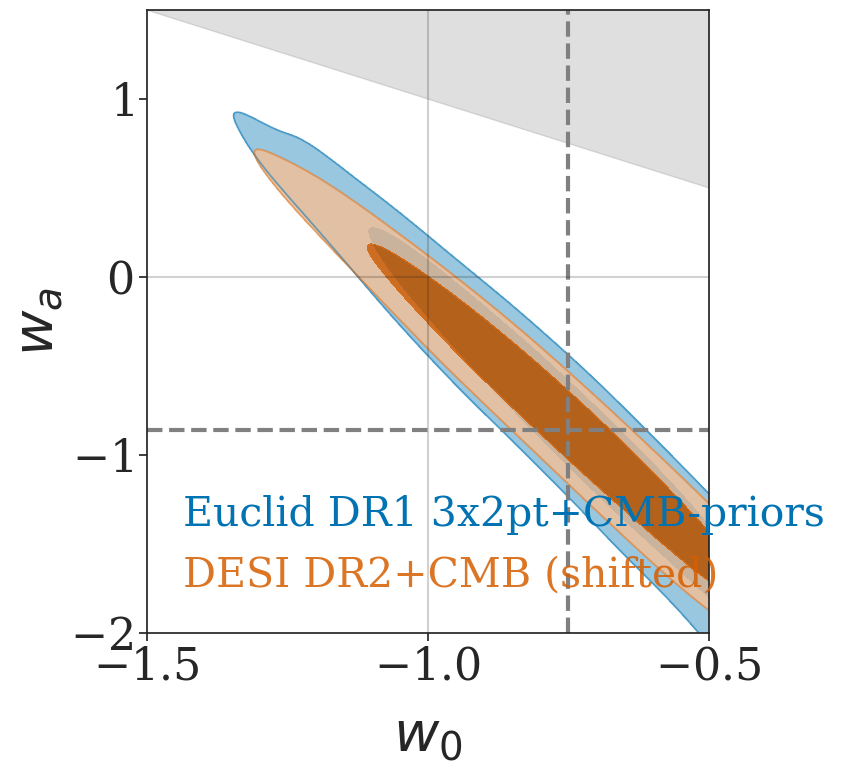

In [30]:

plt.rcParams.update({'font.size':16})
palette = sns.color_palette('colorblind') 
colors = palette                            

g = getdist.plots.get_single_plotter(width_inch=8, ratio=1)#ratio=1)

g.settings.linewidth=3     
g.settings.legend_fontsize=24 
g.settings.axes_fontsize=32
g.settings.axes_labelsize=40


x=np.linspace(-3, 0., 100)
g.plot_2d([samples[0], samples_desi_cmb], 
          'w0', 'wa_shift',  
          filled=[True, #False, 
                  True, True, True, True], lims=[-1.5, -0.5, -2, 1.5], 
          contour_args = [{'filled':False, 'color': colors[0]}, 
{'filled':True, 'color': colors[3], 'ls': '-'}, {'filled':False, 'color': colors[4], 'ls': '-'}], 
line_args=[ {'color': colors[0]}, 
{'color': colors[3], 'ls': '-'},  {'color': colors[4], 'ls': '-'}])
g.add_y_marker(-0.86, lw=3)
g.add_x_marker(-0.75, lw=3)
g.add_legend([
'Euclid DR1 3x2pt+CMB-priors',
'DESI DR2+CMB (shifted)'
], colored_text=True, legend_loc='lower left', #bbox_to_anchor=(1.9, 1.), 
fontsize=29.5)  #27)
ax = g.subplots[0, 0]
ax.axvline(x=-1., color='k',ls='-', alpha=0.2)  
ax.axhline(y=0, color='k',ls='-', alpha=0.2) 
#ax.plot(x,-x, color='k',ls='--')  
ax.fill_between(xx, -xx, np.ones(len(xx))*4, color='grey', alpha=0.25)
#ax.axvline(x=-0.3, color='k',ls='--')  
#plt.savefig('figs/paper_draft/'+file_name+'.png')   
plt.show()

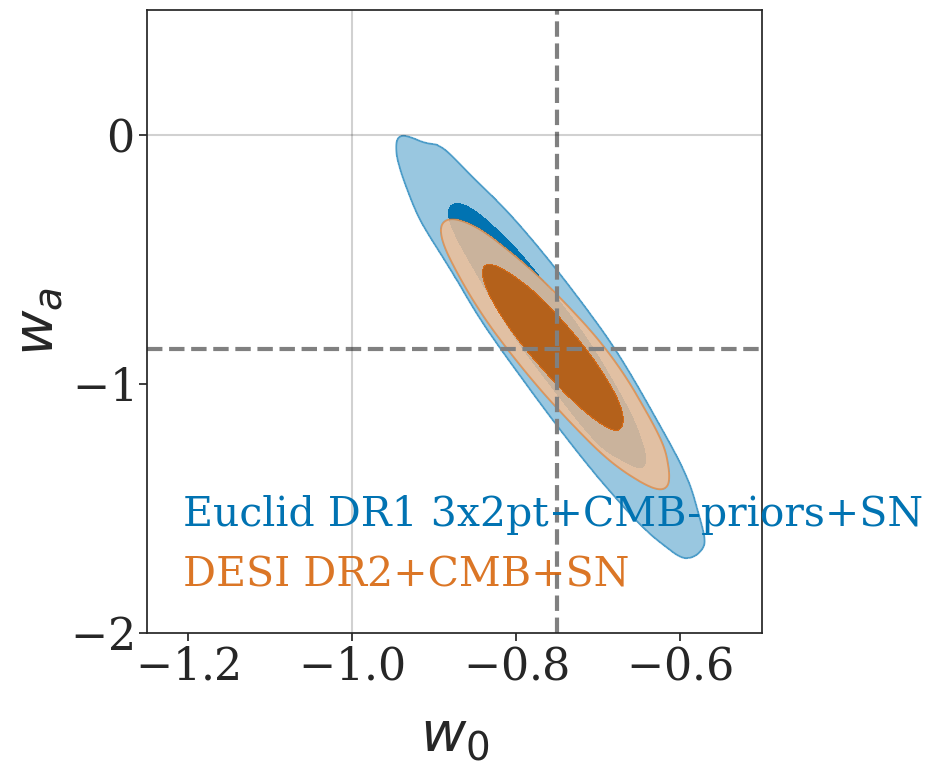

In [31]:
plt.rcParams.update({'font.size':16})
palette = sns.color_palette('colorblind') 
colors = palette                            

g = getdist.plots.get_single_plotter(width_inch=8, ratio=1)#ratio=1)

g.settings.linewidth=3     
g.settings.legend_fontsize=24 
g.settings.axes_fontsize=32
g.settings.axes_labelsize=40


x=np.linspace(-3, 0., 100)
g.plot_2d([samples[2], samples_desi_cmb_sn], 
          'w0', 'wa',  
          filled=[True, #False, 
                  True, True, True, True], lims=[-1.25, -0.5, -2, 0.5], 
          contour_args = [{'filled':False, 'color': colors[0]}, 
{'filled':True, 'color': colors[3], 'ls': '-'}, {'filled':False, 'color': colors[4], 'ls': '-'}], 
line_args=[ {'color': colors[0]}, 
{'color': colors[3], 'ls': '-'},  {'color': colors[4], 'ls': '-'}])
g.add_y_marker(-0.86, lw=3)
g.add_x_marker(-0.75, lw=3)
g.add_legend([
'Euclid DR1 3x2pt+CMB-priors+SN',
'DESI DR2+CMB+SN'
], colored_text=True, legend_loc='lower left', #bbox_to_anchor=(1.9, 1.), 
fontsize=29.5)  #27)
ax = g.subplots[0, 0]
ax.axvline(x=-1., color='k',ls='-', alpha=0.2)  
ax.axhline(y=0, color='k',ls='-', alpha=0.2) 
#ax.plot(x,-x, color='k',ls='--')  
ax.fill_between(xx, -xx, np.ones(len(xx))*4, color='grey', alpha=0.25)
#ax.axvline(x=-0.3, color='k',ls='--')  
#plt.savefig('figs/paper_draft/'+file_name+'.png')   
plt.show()

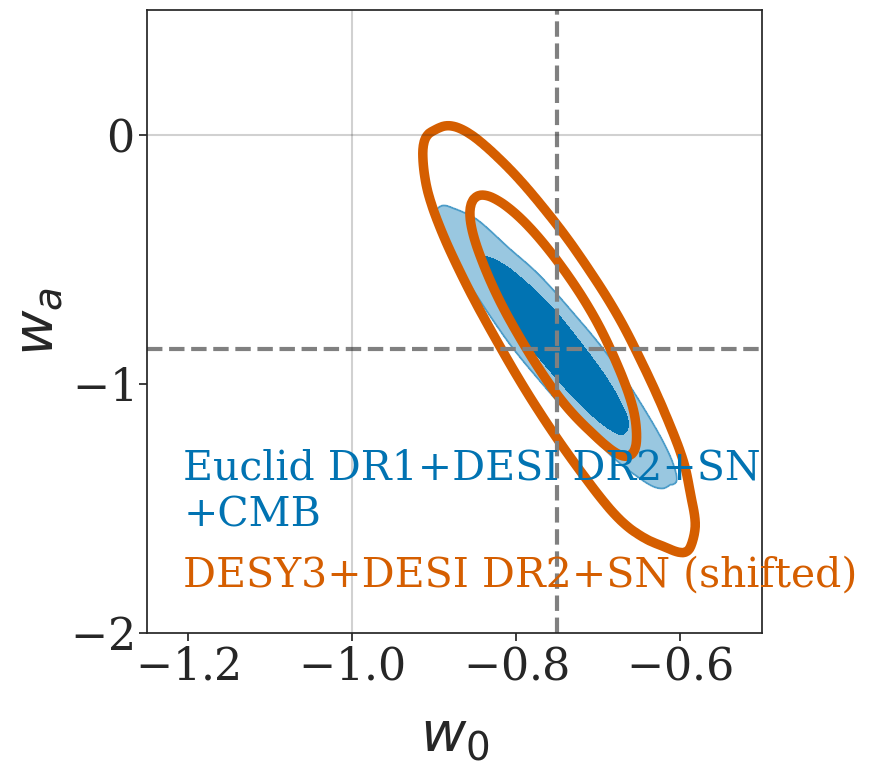

In [20]:
plt.rcParams.update({'font.size':16})
palette = sns.color_palette('colorblind') 
colors = palette                            

g = getdist.plots.get_single_plotter(width_inch=8, ratio=1)#ratio=1)

g.settings.linewidth=3     
g.settings.legend_fontsize=24 
g.settings.axes_fontsize=32
g.settings.axes_labelsize=40


x=np.linspace(-3, 0., 100)
g.plot_2d([samples[3], samples_desi_des_sn], 
          'w0', 'wa_shift',  
          filled=[True, False, 
                  True, True, True, True], lims=[-1.25, -0.5, -2, 0.5], 
          contour_args = [{'filled':False, 'color': colors[0]}, 
{'filled':True, 'color': colors[3], 'ls': '-'}, {'filled':False, 'color': colors[4], 'ls': '-'}], 
line_args=[ {'color': colors[0]}, 
{'color': colors[3], 'ls': '-'},  {'color': colors[4], 'ls': '-'}])
g.add_y_marker(-0.86, lw=3)
g.add_x_marker(-0.75, lw=3)
g.add_legend([
'Euclid DR1+DESI DR2+SN\n+CMB',
'DESY3+DESI DR2+SN (shifted)'
], colored_text=True, legend_loc='lower left', #bbox_to_anchor=(1.9, 1.), 
fontsize=29.5)  #27)
ax = g.subplots[0, 0]
ax.axvline(x=-1., color='k',ls='-', alpha=0.2)  
ax.axhline(y=0, color='k',ls='-', alpha=0.2) 
#ax.plot(x,-x, color='k',ls='--')  
ax.fill_between(xx, -xx, np.ones(len(xx))*4, color='grey', alpha=0.25)
#ax.axvline(x=-0.3, color='k',ls='--')  
#plt.savefig('figs/paper_draft/'+file_name+'.png')   
plt.show()